## Exploratory data analysis of SMARD generation and price data from August 2025 through July 2026
### SMARD generation data for Germany only and price data for Germany/Luxmembourg and France

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
sys.path.append(str(project_root))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.utils.cleaning import clean_smard_generation, clean_smard_price

In [3]:
gen_raw = pd.read_csv(
    "data/raw/Actual_generation_202408010000_202608010000_Quarterhour.csv",
    sep=';'
)
price_raw = pd.read_csv(
    "data/raw/Day-ahead_prices_202408010000_202608010000_Quarterhour.csv",
    sep=';'
)

gen = clean_smard_generation(gen_raw)
price = clean_smard_price(price_raw)

/var/folders/3x/q7ldnr7x6xs9pmgvyfk2kqd40000gn/T/ipykernel_88239/4042589641.py:5: DtypeWarning: Columns (0: Belgium [€/MWh] Original resolutions, 1: Slovenia [€/MWh] Original resolutions) have mixed types. Specify dtype option on import or set low_memory=False.
  price_raw = pd.read_csv(


In [4]:
gen.head()

,Start date,End date,energy_source,generation_mwh
0,2024-08-01 00:00:00,2024-08-01 00:15:00,Biomass,945.25
1,2024-08-01 00:15:00,2024-08-01 00:30:00,Biomass,936.50
2,2024-08-01 00:30:00,2024-08-01 00:45:00,Biomass,930.00
3,2024-08-01 00:45:00,2024-08-01 01:00:00,Biomass,929.25
4,2024-08-01 01:00:00,2024-08-01 01:15:00,Biomass,918.75


## First look at total generation in Germany by source

In [5]:
# How much energy was generated by source from Aug 2024 through July 2026 and what is the average?
gen.groupby('energy_source')['generation_mwh'].agg(['sum', 'mean']).sort_values('sum', ascending=False)

,sum,mean
energy_source,,
Wind onshore,2.142851e+08,3057.720487
Photovoltaics,1.512803e+08,2158.679827
Lignite,1.371498e+08,1957.046678
Fossil gas,1.197354e+08,1708.552656
Biomass,7.135124e+07,1018.139842
Hard coal,5.977770e+07,852.992300
Wind offshore,5.301952e+07,756.557051
Other conventional,2.978245e+07,424.977941
Hydropower,2.865129e+07,408.836886


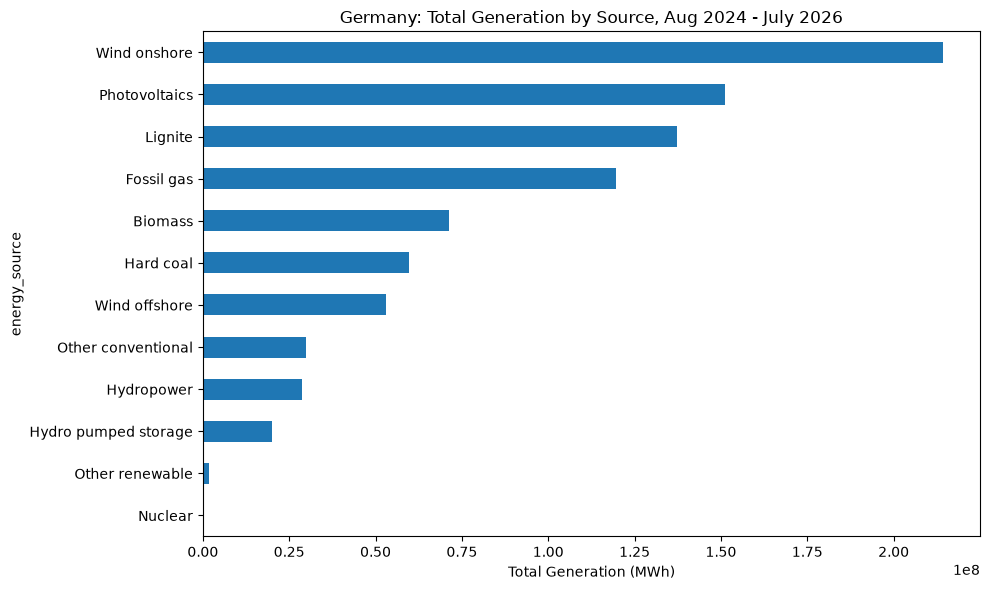

In [6]:
totals = gen.groupby('energy_source')['generation_mwh'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
totals.plot(kind='barh', ax=ax)
ax.set_xlabel('Total Generation (MWh)')
ax.set_title('Germany: Total Generation by Source, Aug 2024 - July 2026')
ax.invert_yaxis()  # largest bar on top
plt.tight_layout()
plt.show()

In [7]:
# Adding month year column to dataframe
gen['year_month'] = gen['Start date'].dt.to_period('M')

## Monthly wind and solar enery generation

In [8]:
gen[gen['energy_source'].isin(['Wind onshore','Photovoltaics'])].groupby(['year_month','energy_source'])['generation_mwh'].agg(['sum', 'mean'])

sum         mean
year_month energy_source                          
2024-08    Photovoltaics   8941062.25  3004.389197
           Wind onshore    5184448.50  1742.086190
2024-09    Photovoltaics   6161317.50  2139.346354
           Wind onshore    8943181.25  3105.271267
2024-10    Photovoltaics   3561570.50  1195.157886
           Wind onshore    8368162.75  2808.108305
2024-11    Photovoltaics   1529686.25   531.141059
           Wind onshore   10259467.00  3562.314931
2024-12    Photovoltaics   1036765.75   348.375588
           Wind onshore   13708154.25  4606.234627
2025-01    Photovoltaics   1627464.75   546.863155
           Wind onshore   13201131.50  4435.864079
2025-02    Photovoltaics   3018648.00  1123.008929
           Wind onshore    7227404.00  2688.766369
2025-03    Photovoltaics   6906310.12  2323.792100
           Wind onshore    6491692.25  2184.284068
2025-04    Photovoltaics   8951024.50  3107.994618
           Wind onshore    5843161.25  2028.875434
2025-05    Photovoltaics  10217138.50  3433.178259
           Wind onshore    7858113.25  2640.495044
2025-06    Photovoltaics  10536110.75  3658.371788
           Wind onshore    8676526.75  3012.682899
2025-07    Photovoltaics   9056373.39  3043.136220
           Wind onshore    6167801.12  2072.513817
2025-08    Photovoltaics   9672278.59  3250.093612
           Wind onshore    5459159.60  1834.395027
2025-09    Photovoltaics   6435895.31  2234.685872
           Wind onshore    9721142.20  3375.396597
2025-10    Photovoltaics   3642622.38  1222.356503
           Wind onshore   13695534.32  4595.816886
2025-11    Photovoltaics   2210900.16   767.673667
           Wind onshore    9952192.69  3455.622462
2025-12    Photovoltaics   1509063.87   507.077913
           Wind onshore   12474033.84  4191.543629
2026-01    Photovoltaics   1636838.90   550.013071
           Wind onshore   13035817.60  4380.315054
2026-02    Photovoltaics   2535863.48   943.401592
           Wind onshore   11140080.66  4144.375246
2026-03    Photovoltaics   7301704.95  2456.832083
           Wind onshore    9115869.23  3067.250750
2026-04    Photovoltaics  10046414.96  3488.338528
           Wind onshore    7865924.70  2731.223854
2026-05    Photovoltaics  11549003.81  3880.713646
           Wind onshore    5491508.08  1845.264812
2026-06    Photovoltaics  11160706.43  3875.245288
           Wind onshore    6396756.07  2221.095858
2026-07    Photovoltaics  12035517.20  4044.192608
           Wind onshore    8007788.84  2690.789261

In [9]:
# reshape for graphing
monthly = gen[gen['energy_source'].isin(['Wind onshore', 'Photovoltaics'])] \
    .groupby(['year_month', 'energy_source'])['generation_mwh'] \
    .sum() \
    .unstack()

monthly.head()

energy_source,Photovoltaics,Wind onshore
year_month,,
2024-08,8941062.25,5184448.50
2024-09,6161317.50,8943181.25
2024-10,3561570.50,8368162.75
2024-11,1529686.25,10259467.00
2024-12,1036765.75,13708154.25


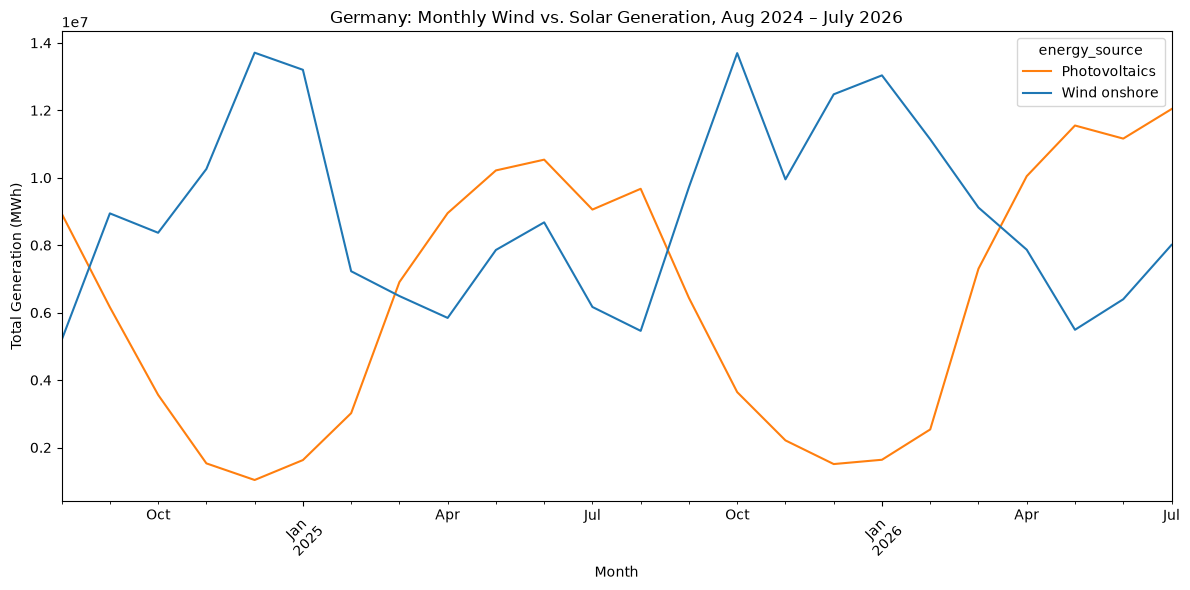

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
monthly.plot(ax=ax, color={'Wind onshore': 'tab:blue', 'Photovoltaics': 'tab:orange'})
ax.set_xlabel('Month')
ax.set_ylabel('Total Generation (MWh)')
ax.set_title('Germany: Monthly Wind vs. Solar Generation, Aug 2024 – July 2026')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Wind and solar move in seasonal cycles, overlapping around September/October and March/April each year

## First look at day-ahead prices by country: Germany/Luxembourg and France

In [11]:
# check out price metrics from Aug 2024 through July 2026
price.groupby('country')['price_eur_mwh'].agg(['min','max','mean','std'])

,min,max,mean,std
country,,,,
France,-498.65,473.28,65.283332,49.843583
Germany/Luxembourg,-499.99,936.28,93.242291,58.367323


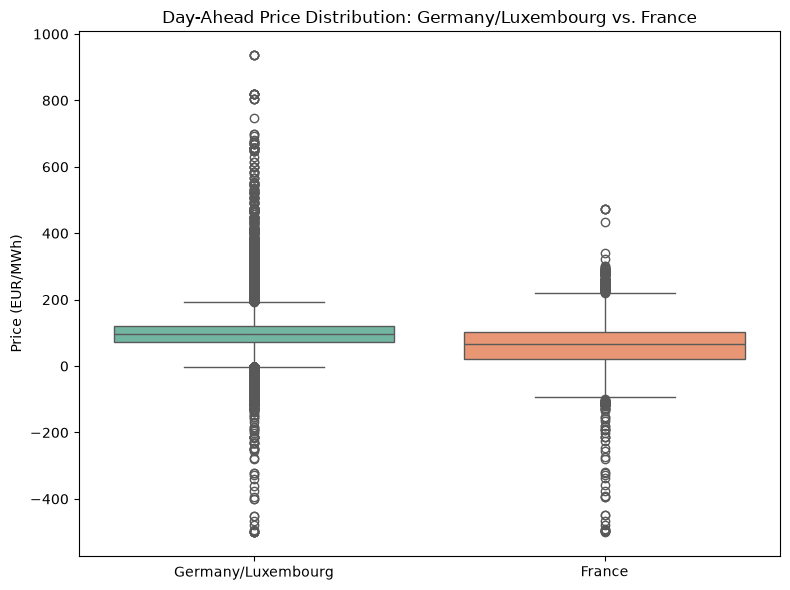

In [12]:
# box plot comparing prices

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=price, x='country', y='price_eur_mwh', hue='country', palette='Set2', legend=False, ax=ax)
ax.set_ylabel('Price (EUR/MWh)')
ax.set_xlabel('')
ax.set_title('Day-Ahead Price Distribution: Germany/Luxembourg vs. France')
plt.tight_layout()
plt.show()

In [13]:
# checking the quartile ranges, France looks wider than Germany
price.groupby('country')['price_eur_mwh'].quantile([0.25, 0.5, 0.75])

country                 
France              0.25     21.96
                    0.50     67.29
                    0.75    101.25
Germany/Luxembourg  0.25     71.00
                    0.50     96.61
                    0.75    120.33
Name: price_eur_mwh, dtype: float64

In [14]:
# France IQR
101.25-21.96

79.28999999999999

In [15]:
# Germany IQR
120.33-71

49.33

Germany has more extreme price events, but its typical/day-to-day price range is actually more predictable than France's. Both countries show extreme negative price events (~-€500/MWh) — worth investigating frequency/conditions.



## Monthly average day-ahead prices

In [16]:
# plotting prices by month

price['year_month'] = price['Start date'].dt.to_period('M')

In [17]:
price.groupby(['year_month','country'])['price_eur_mwh'].agg(['mean'])

mean
year_month country                       
2024-08    France               54.560699
           Germany/Luxembourg   82.047177
2024-09    France               51.857042
           Germany/Luxembourg   78.309972
2024-10    France               62.055718
           Germany/Luxembourg   86.096550
2024-11    France              100.532625
           Germany/Luxembourg  113.906444
2024-12    France               98.176734
           Germany/Luxembourg  108.315591
2025-01    France              102.274704
           Germany/Luxembourg  114.140161
2025-02    France              122.658482
           Germany/Luxembourg  128.522366
2025-03    France               76.878560
           Germany/Luxembourg   94.727497
2025-04    France               42.210736
           Germany/Luxembourg   77.935653
2025-05    France               19.376196
           Germany/Luxembourg   67.338629
2025-06    France               40.742222
           Germany/Luxembourg   63.987500
2025-07    France               57.977513
           Germany/Luxembourg   87.795228
2025-08    France               54.439758
           Germany/Luxembourg   76.990255
2025-09    France               34.808056
           Germany/Luxembourg   83.511083
2025-10    France               57.470674
           Germany/Luxembourg   84.402034
2025-11    France               59.127045
           Germany/Luxembourg  101.881497
2025-12    France               68.731623
           Germany/Luxembourg   93.469446
2026-01    France              100.650276
           Germany/Luxembourg  110.090383
2026-02    France               46.020424
           Germany/Luxembourg   96.576391
2026-03    France               63.850680
           Germany/Luxembourg   99.287598
2026-04    France               39.798736
           Germany/Luxembourg   78.515556
2026-05    France               52.202241
           Germany/Luxembourg   97.535853
2026-06    France               66.072514
           Germany/Luxembourg  109.515788
2026-07    France               95.233243
           Germany/Luxembourg  105.446895

In [18]:
# reshape to graph

monthly_price = price.groupby(['year_month', 'country'])['price_eur_mwh'] \
    .mean() \
    .unstack()

monthly_price.head()

country,France,Germany/Luxembourg
year_month,,
2024-08,54.560699,82.047177
2024-09,51.857042,78.309972
2024-10,62.055718,86.096550
2024-11,100.532625,113.906444
2024-12,98.176734,108.315591


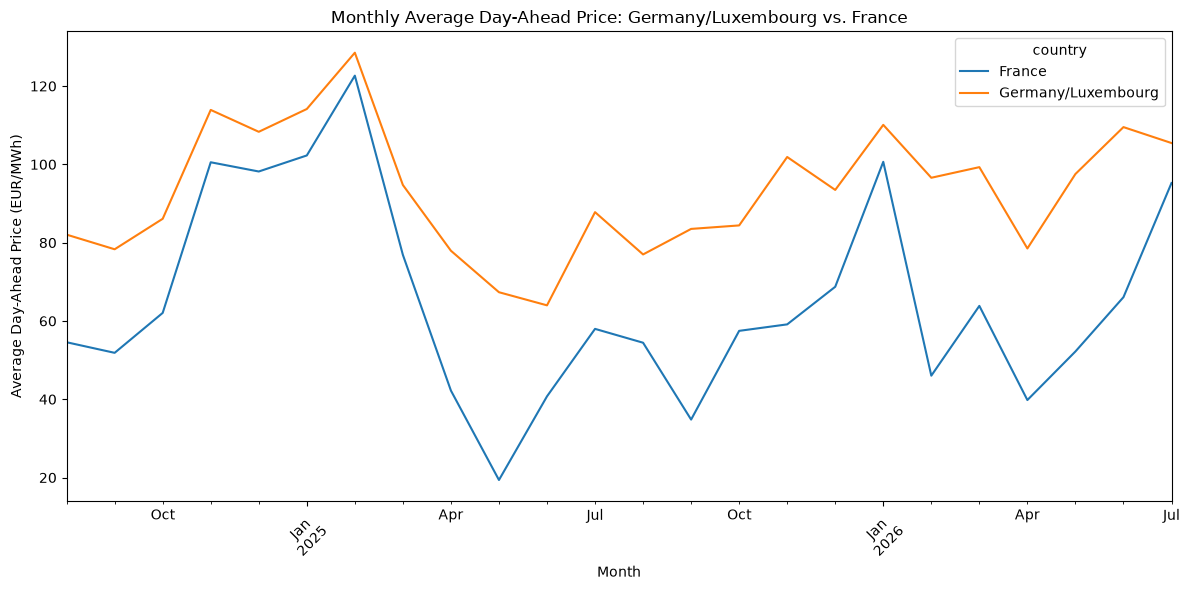

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
monthly_price = price.groupby(['year_month', 'country'])['price_eur_mwh'].mean().unstack()
monthly_price.plot(ax=ax, color={'Germany/Luxembourg': 'tab:orange', 'France': 'tab:blue'})
ax.set_xlabel('Month')
ax.set_ylabel('Average Day-Ahead Price (EUR/MWh)')
ax.set_title('Monthly Average Day-Ahead Price: Germany/Luxembourg vs. France')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Germany/Luxembourg prices stay consistently above France throughout the full 2-year period (no crossover). France shows much larger month-to-month volatility despite Germany having higher within-month (15-min) price spread — worth investigating French nuclear outage schedules as a possible driver in later analysis. (Quick check online suggests that the big dip in prices from Feb 2025 - May 2025 is due to nuclear plants coming back online and then an increase in solar energy.)